In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
np.random.seed(RANDOM_STATE)

## Task 1: Problem Definition & Success Metric

**Target:** income = >50K is the positive class (1); <=50K is negative (0).

**Business objective:** this mirrors a targeted-marketing / credit-screening use case since we want to flag
likely high-income individuals for a premium offer or credit product, while keeping the cost of contacting the wrong people low.

**Chosen metric:** we prioritize precision over recall. Every positive prediction triggers an outreach cost (a call, a mailer, a credit review), so false positives are expensive and repetitive, while missing some true positives (false negatives) just means fewer opportunities pursued this cycle. We'll still report ROC AUC and F1 as secondary metrics for a fuller picture, but precision on the
hold-out set is our primary metric.

**Explanation:** We're trying to spot people likely to earn over $50K a year so we can focus our outreach budget on them instead of contacting everyone. We care most about being right when we do reach out because wasting a contact on the wrong person costs us more than missing an occasional good lead.

## Task 2: Data Load & Quick EDA

In [3]:
# Loading dataset
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

print(df.shape)
df.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
# Converting target to binary 0/1
target_col = 'class' if 'class' in df.columns else 'income'
df[target_col] = df[target_col].astype(str).str.strip()
df['target'] = (df[target_col] == '>50K').astype(int)

df[['target']].value_counts(normalize=False)

,count
target,
0,37155
1,11687


In [5]:
# Cleaning missing values
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

print("Missing values per column:")
df.isna().sum()[df.isna().sum() > 0]

Missing values per column:


,0
workclass,2799
occupation,2809
native-country,857


In [6]:
# Data shape & column types
print("Shape:", df.shape)
df.dtypes

Shape: (48842, 16)


,0
age,int64
workclass,category
fnlwgt,int64
education,category
education-num,int64
marital-status,category
occupation,category
relationship,category
race,category
sex,category


In [7]:
# Numeric summaries
df.select_dtypes(include=[np.number]).describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,target
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382,0.239282
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444,0.426649
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [8]:
# Value counts for a few key categorical columns
for col in ['workclass', 'education', 'occupation', 'sex', 'race']:
    if col in df.columns:
        print(f"--- {col} ---")
        print(df[col].value_counts(dropna=False).head(10))
        print()

--- workclass ---
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

--- education ---
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
NaN                  2809
Transport-moving     2355
Handlers-cleaners    2072
Name: count, dtype: int64

--- sex ---
sex
Male      32650
Female    16192
Name: count, dtype: int64

--- race ---
race
White                 4176

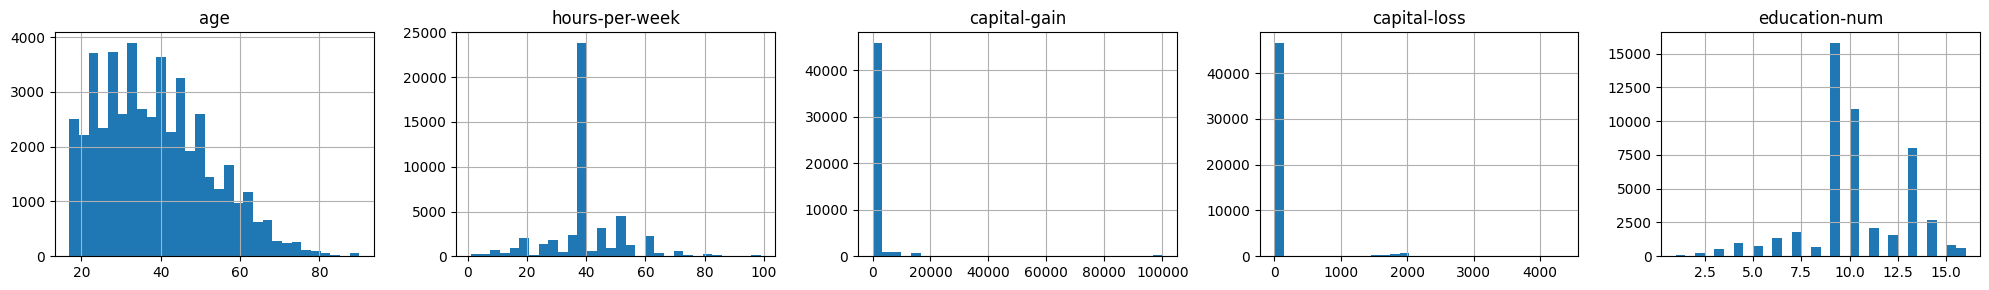

In [9]:
# Histogram
num_cols = ['age', 'hours-per-week', 'capital-gain', 'capital-loss', 'education-num']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 3))
for ax, col in zip(axes, num_cols):
    df[col].hist(ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4784/268658940.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('education')['target'].mean().sort_values().plot(kind='barh', ax=axes[0], title='>50K rate by education')
/tmp/ipykernel_4784/268658940.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('workclass')['target'].mean().sort_values().plot(kind='barh', ax=axes[1], title='>50K rate by workclass')


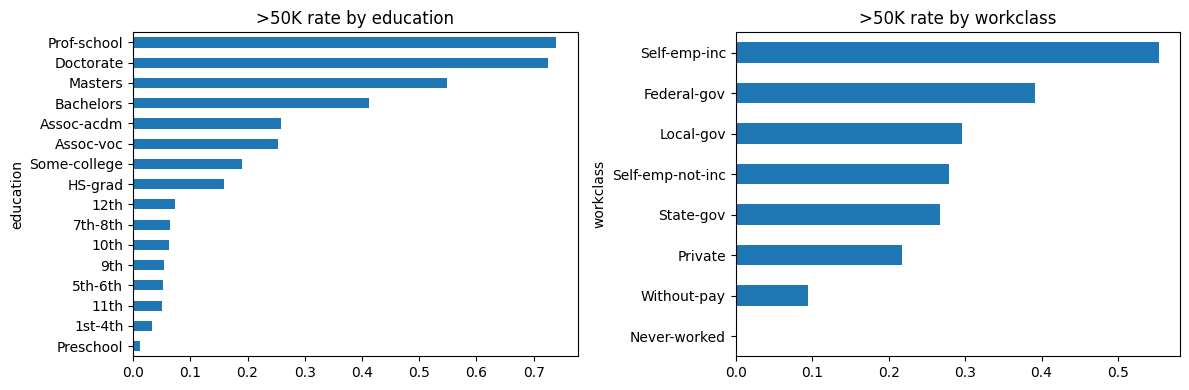

In [10]:
# Bar plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby('education')['target'].mean().sort_values().plot(kind='barh', ax=axes[0], title='>50K rate by education')
df.groupby('workclass')['target'].mean().sort_values().plot(kind='barh', ax=axes[1], title='>50K rate by workclass')

plt.tight_layout()
plt.show()

In [11]:
# Summary table
class_counts = df['target'].value_counts().rename({0: '<=50K', 1: '>50K'})
base_rate = df['target'].mean()

summary_table = pd.DataFrame({
    'metric': ['negatives (<=50K)', 'positives (>50K)', 'base_rate_positive'],
    'value': [class_counts.get('<=50K', 0), class_counts.get('>50K', 0), round(base_rate, 4)]
})
print(summary_table)

notable_features = df[['age', 'education-num', 'hours-per-week']].describe().T
notable_features

               metric       value
0   negatives (<=50K)  37155.0000
1    positives (>50K)  11687.0000
2  base_rate_positive      0.2393


,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
education-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


## Task 3: Reproducible Train / Hold-out Split

**Why its necessary:** if we tune hyperparameters or select features using the same data we evaluate on, we overfit to that data's quirks and get an overly optimistic performance estimate that won't generalize to new, unseen individuals. The hold-out set simulates "future" data we haven't touched, so its score is an honest estimate of real-world performance. Using it during tuning leaks information and inflates our reported metrics.

In [12]:
feature_cols = [c for c in df.columns if c not in [target_col, 'target']]
X = df[feature_cols]
y = df['target']

# 80-20 (20 for holdout)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# 80-10 (basically 70/10/20)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test (hold-out):", X_test.shape)
print("Train positive rate:", y_train.mean().round(3),
      " Dev positive rate:", y_dev.mean().round(3),
      " Test positive rate:", y_test.mean().round(3))

Train: (34188, 14)  Dev: (4885, 14)  Test (hold-out): (9769, 14)
Train positive rate: 0.239  Dev positive rate: 0.239  Test positive rate: 0.239


## Task 4: Simple Baselines

In [20]:
# Baseline 1: Majority-class predictor
majority_class = y_train.mode()[0]
pred_majority = np.full(shape=len(y_test), fill_value=majority_class)
# Score for AUC purpose
score_majority = pred_majority.astype(float)

In [14]:
# Baseline 2: Single-feature rule-based classifier
rule_condition = (X_test['education-num'] >= 13) | (X_test['capital-gain'] > 0)
pred_rule = rule_condition.astype(int).values
score_rule = pred_rule.astype(float)

In [15]:
def evaluate(y_true, y_pred, y_score, name):
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }
    return metrics

results = [
    evaluate(y_test, pred_majority, score_majority, 'Majority-class'),
    evaluate(y_test, pred_rule, score_rule, 'Rule-based (edu>=13 or cap-gain>0)'),
]
metrics_df = pd.DataFrame(results).set_index('model').round(4)
metrics_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Majority-class,0.7607,0.0000,0.0000,0.0000,0.5000,0.2393
Rule-based (edu>=13 or cap-gain>0),0.7520,0.4852,0.5967,0.5352,0.6987,0.3860


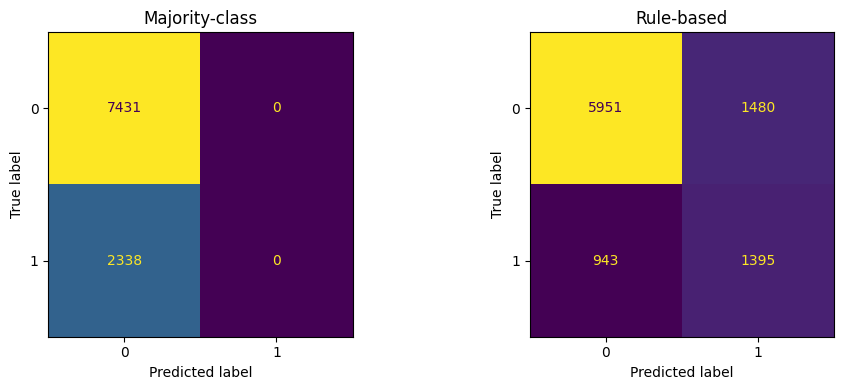

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_majority)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Majority-class')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_rule)).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Rule-based')
plt.tight_layout()
plt.show()

**Interpretation:** the majority-class baseline gets high accuracy for free (because the classes are imbalanced) but has zero precision/recall/F1 on the positive class — it never predicts >50K, so it's
useless for our actual goal. The rule-based baseline trades some accuracy for real signal: it achieves non-trivial precision and recall by using two features. It wins on every metric that matters for this task (precision, recall, F1, ROC AUC, PR AUC), even though it's still a very simple model. For a real model to be considered useful, it should clearly beat the rule-based baseline's precision and PR AUC by a meaningful margin (e.g., several points), not just match it.

## Task 5: Initial Error Analysis & Next Steps

In [17]:
test_df = X_test.copy()
test_df['y_true'] = y_test.values
test_df['y_pred'] = pred_rule

false_positives = test_df[(test_df['y_true'] == 0) & (test_df['y_pred'] == 1)]
false_negatives = test_df[(test_df['y_true'] == 1) & (test_df['y_pred'] == 0)]

print("False positives sample:")
display_cols = ['age', 'education', 'education-num', 'occupation', 'hours-per-week', 'capital-gain']
display_cols = [c for c in display_cols if c in test_df.columns]
fp_sample = false_positives[display_cols].sample(min(10, len(false_positives)), random_state=RANDOM_STATE)
fp_sample

False positives sample:


,age,education,education-num,occupation,hours-per-week,capital-gain
31242,35,Bachelors,13,Sales,50,0
866,40,Bachelors,13,Exec-managerial,39,0
19163,53,Bachelors,13,Exec-managerial,40,0
39000,26,Bachelors,13,Sales,50,0
46155,63,Bachelors,13,Transport-moving,40,0
29664,32,Bachelors,13,Sales,45,0
47129,17,11th,7,Craft-repair,40,594
36843,43,Bachelors,13,Prof-specialty,21,0
24705,34,Masters,14,Prof-specialty,24,0
31388,42,Bachelors,13,Exec-managerial,35,4650


In [18]:
print("False negatives sample:")
fn_sample = false_negatives[display_cols].sample(min(10, len(false_negatives)), random_state=RANDOM_STATE)
fn_sample

False negatives sample:


,age,education,education-num,occupation,hours-per-week,capital-gain
4338,44,12th,8,Exec-managerial,55,0
20143,41,Assoc-voc,11,Tech-support,48,0
22663,58,Some-college,10,Exec-managerial,65,0
44384,52,12th,8,Exec-managerial,50,0
39434,33,Some-college,10,Adm-clerical,40,0
9088,73,Some-college,10,Sales,20,0
3141,38,Assoc-voc,11,Tech-support,50,0
42511,54,HS-grad,9,Exec-managerial,40,0
48297,62,HS-grad,9,NaN,40,0
14433,43,Some-college,10,Exec-managerial,40,0


In [19]:
# Pattern check
pattern_check = pd.DataFrame({
    'false_positives_mean_age': [false_positives['age'].mean()],
    'false_negatives_mean_age': [false_negatives['age'].mean()],
    'false_positives_mean_hours': [false_positives['hours-per-week'].mean()],
    'false_negatives_mean_hours': [false_negatives['hours-per-week'].mean()],
})
pattern_check.round(1)

,false_positives_mean_age,false_negatives_mean_age,false_positives_mean_hours,false_negatives_mean_hours
0,38.2,43.9,40.2,45.0


**Observed patterns:**
- False positives often have high education-num but work in lower-paying occupations or fewer hours:  education alone overstates their likely income.
- False negatives often have capital-gain == 0 and moderate education but work very high hours/week or hold occupations not captured by our simple rule, which means the rule misses income signals outside education/capital-gain.

**Data/feature issues to fix tomorrow:**
1. Encode categorical features properly (one-hot or target encoding) instead of ignoring them.
2. Handle missing values in workclass, occupation, native-country (currently dropped/NaN) via  imputation or an explicit "missing" category.
3. Address the strong right-skew in capital-gain/capital-loss (mostly zeros with rare large values). We can consider binarizing or log-transforming.
4. Bucket rare categories in high-cardinality columns like native-country and occupation.
5. Check for correlated/redundant features (education vs education-num) and drop duplicates.
6. Consider interaction features (e.g., hours-per-week x occupation) since a single-feature rule clearly under-fits.

**Primary metric for the rest of the week:** we'll keep optimizing precision (with PR AUC as a secondary check), since our baseline rule already shows precision below what a deployable model needs, and its to improve categorical encoding and adding interaction features that should directly reduce the false-positive pattern seen above.